In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import glob
import numpy as np

from IPython.display import HTML
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation
from torch.autograd import Variable
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

In [2]:
def groups_of_three(arr):
    """
    Splits arr into non-overlapping groups of three elements.
    If the length is not a multiple of 3, the last group will be shorter.
    """
    return [arr[i:i+3] for i in range(0, len(arr), 3)]

coco_connections = [
    # Head
    (0, 1), (0, 2), (1, 3), (2, 4),
    # Torso
    (5, 6), (5, 11), (6, 12), (11, 12),
    # Left Arm
    (5, 7), (7, 9),
    # Right Arm
    (6, 8), (8, 10),
    # Left Leg
    (11, 13), (13, 15),
    # Right Leg
    (12, 14), (14, 16)
]

def plot_line(axs, pt1, pt2, **kwargs):
    """
    Plots a line between two points on the given matplotlib axis.
    pt1, pt2: (x, y) tuples or arrays
    axs: matplotlib axis object
    kwargs: additional arguments for axs.plot (e.g., color, linewidth)
    """
    x_values = [pt1[0], pt2[0]]
    y_values = [pt1[1], pt2[1]]
    axs.plot(x_values, y_values, **kwargs)

def calculate_node_velocity(nodes, dt=1.0):
    """
    Calculate the velocity of each node over time.
    nodes: numpy array of shape (frames, num_nodes, 2) with (x, y) positions.
    dt: time difference between frames (default 1.0, set to actual frame interval if known).
    Returns:
        velocities: numpy array of shape (frames-1, num_nodes, 2) with (vx, vy) velocities.
        speeds: numpy array of shape (frames-1, num_nodes) with speed magnitudes.
    """
    velocities = (nodes[1:] - nodes[:-1]) / dt
    speeds = np.linalg.norm(velocities, axis=2)
    return velocities, speeds

**DATASET**

In [3]:
import numpy as np
import torch
import glob
import os
from torch.utils.data import Dataset

def normalize(data, data_max, data_min):
    return (data - data_min) * 2 / (data_max - data_min) - 1

def unnormalize(data, data_max, data_min):
    return (data + 1) * (data_max - data_min) / 2 + data_min

class PoseDataset(Dataset):
    # Removed pitch_type from the init arguments
    def __init__(self, data_path, mode, data_len=-1, test_full=False):
        self.data_path = data_path
        self.mode = mode
        self.train_data_len = data_len
        self.test_full = test_full

        # 1. Use the '*' wildcard to grab files from ALL pitch type subfolders
        train_files = glob.glob(os.path.join(data_path, 'train', '*', '*.txt'))
        if not train_files:
            raise ValueError(f"No training files found in {os.path.join(data_path, 'train')}")
            
        train_locs, train_vels = self._load_and_process_files(train_files)

        # 2. Calculate min/max values across the entire training set for normalization
        self.loc_max = max(loc.max() for loc in train_locs)
        self.loc_min = min(loc.min() for loc in train_locs)
        self.vel_max = max(vel.max() for vel in train_vels)
        self.vel_min = min(vel.min() for vel in train_vels)

        # 3. Load the requested split (train, val, or test)
        if mode == 'train':
            split_locs, split_vels = train_locs, train_vels
        else:
            # Use the wildcard '*' here as well
            split_files = glob.glob(os.path.join(data_path, mode, '*', '*.txt'))
            
            # Safeguard
            if not split_files:
                raise ValueError(f"No {mode} files found in directory: {os.path.join(data_path, mode)}. Please check your folder structure!")
                
            split_locs, split_vels = self._load_and_process_files(split_files)

        # 4. Normalize and build the final feature tensors
        self.feat = []
        for loc, vel in zip(split_locs, split_vels):
            loc_norm = normalize(loc, self.loc_max, self.loc_min)
            vel_norm = normalize(vel, self.vel_max, self.vel_min)
            
            # Concatenate loc and vel into shape: (frames, 17, 4)
            combined = np.concatenate([loc_norm, vel_norm], axis=-1).astype(np.float32)
            
            # Truncate test sequences if requested
            if self.mode == 'test' and not self.test_full:
                combined = combined[:49]
                
            self.feat.append(torch.from_numpy(combined))

    def _load_and_process_files(self, file_paths):
        """Helper to load .txt files, extract 17 keypoints, and compute velocity."""
        all_locs = []
        all_vels = []
        
        for file_path in file_paths:
            # Load text file -> shape: (frames, 56)
            data = np.loadtxt(file_path)
            frames = data.shape[0]
            
            # Extract x, y coordinates for the 17 nodes
            loc = np.zeros((frames, 17, 2))
            for i in range(17):
                loc[:, i, 0] = data[:, 5 + i*3]      # x coordinate
                loc[:, i, 1] = data[:, 5 + i*3 + 1]  # y coordinate
                
            # Calculate velocities (forward difference)
            vel = np.zeros_like(loc)
            vel[1:] = loc[1:] - loc[:-1]  # Assuming dt=1.0 per frame
            
            all_locs.append(loc)
            all_vels.append(vel)
            
        return all_locs, all_vels

    def __getitem__(self, index):
        inputs = self.feat[index]

        # Slice sequences if a target length is specified
        if self.train_data_len > 0:
            size = len(inputs)
            if size > self.train_data_len:
                if self.mode == 'train':
                    # Random crop for data augmentation during training
                    start_ind = np.random.randint(0, size - self.train_data_len)
                else:
                    # Deterministic crop for consistent validation/testing
                    start_ind = 0 
                inputs = inputs[start_ind:start_ind + self.train_data_len]

        return {'inputs': inputs}

    def __len__(self):
        return len(self.feat)

In [4]:
DATA_PATH = "D:/GitHub/BaseballPitch/data/finetuning_dataset/labels"
DATA_LEN = 176 # Adjust to your chosen sequence length

# Clean and simple, no pitch_type required
train_data = PoseDataset(DATA_PATH, 'train', data_len=DATA_LEN)
val_data = PoseDataset(DATA_PATH, 'val', data_len=DATA_LEN)
test_data = PoseDataset(DATA_PATH, 'test', data_len=DATA_LEN, test_full=True)


**NRI MODEL**

In [5]:
def encode_onehot(labels):
    """Convert labels to one-hot encoding."""
    unique_labels = sorted(set(labels))
    onehot = np.eye(len(unique_labels))
    return onehot[np.searchsorted(unique_labels, labels)]

class RefNRIMLP(nn.Module):
    """Two-layer fully-connected ELU net with optional batch norm."""

    def __init__(self, n_in, n_hid, n_out, dropout_prob=0., no_bn=False):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_in, n_hid),
            nn.ELU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(n_hid, n_out),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(n_out) if not no_bn else nn.Identity()
        )

        # Initialize weights
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                m.bias.data.fill_(0.1)
            elif isinstance(m, nn.BatchNorm1d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def forward(self, x):
        # Reshape if needed for BatchNorm
        orig_shape = x.shape
        if len(orig_shape) > 2:
            x = x.view(-1, orig_shape[-1])

        x = self.net(x)

        # Restore original shape if needed
        if len(orig_shape) > 2:
            x = x.view(*orig_shape[:-1], -1)

        return x

In [6]:
class BaseNRI(nn.Module):
    def __init__(self, num_vars, encoder, decoder,
                num_edge_types=2,
                gumbel_temp=0.5,
                prior_variance=5e-5,
                kl_coef=1.0):
        super().__init__()
        self.num_vars = num_vars
        self.encoder = encoder
        self.decoder = decoder
        self.num_edge_types = num_edge_types
        self.gumbel_temp = gumbel_temp
        self.prior_variance = prior_variance
        self.kl_coef = kl_coef

        # Initialize prior distribution
        prior = torch.zeros(num_edge_types).fill_(1.0 / num_edge_types)
        self.log_prior = torch.log(prior).unsqueeze(0).unsqueeze(0)
        self.log_prior = self.log_prior.cuda(non_blocking=True)

    def _compute_nll(self, preds, target):
        neg_log_p = (preds - target) ** 2 / (2 * self.prior_variance)
        const = 0.5 * np.log(2 * np.pi * self.prior_variance)
        return (neg_log_p.sum(-1) + const).view(preds.size(0), -1).mean(dim=1)

    def _compute_kl(self, probs):
        kl = probs * (torch.log(probs + 1e-16) - self.log_prior)
        return kl.sum(-1).view(probs.size(0), -1).mean(dim=1)

    def calculate_loss(self, inputs, is_train=False, teacher_forcing=True, return_edges=False, return_logits=False):
        # 1. Run Dynamic Encoder
        out_dict = self.encoder(inputs)
        enc_logits = out_dict['enc_logits']      # Shape: (B, T, num_edges, 1)
        prior_logits = out_dict['prior_logits']
        
        # 2. Continuous Edge Weights via Sigmoid
        edges = torch.sigmoid(enc_logits)
        
        # 3. Decode
        output = self.decoder(inputs[:, :-1], edges[:, :-1]) 
        target = inputs[:, 1:, :, :] if len(inputs.shape) > 3 else inputs[:, 1:]

        # 4. Calculate Dynamic Loss
        loss_nll = self._compute_nll(output, target)
        
        # Continuous KL Divergence (using Bernoulli for 0.0 to 1.0 bounded values)
        q_dist = torch.distributions.Bernoulli(logits=enc_logits)
        p_dist = torch.distributions.Bernoulli(logits=prior_logits)
        # Sum over edges and time, mean over batch
        loss_kl = torch.distributions.kl.kl_divergence(q_dist, p_dist).sum(dim=(1, 2)).mean(dim=0)
        
        loss = (loss_nll + self.kl_coef * loss_kl).mean()

        if return_edges:
            return loss, loss_nll, loss_kl, edges
        elif return_logits:
            return loss, loss_nll, loss_kl, enc_logits, output
        return loss, loss_nll, loss_kl

    def predict_future(self, inputs, prediction_steps, return_edges=False, return_everything=False):
        B, T_burn, V, F = inputs.shape
        
        # 1. Burn-in Phase
        current_history = inputs.clone()
        out_dict = self.encoder(current_history)
        burn_in_logits = out_dict['prior_logits']
        
        # Get continuous weights using Sigmoid instead of Gumbel-Softmax
        burn_in_edges = torch.sigmoid(burn_in_logits)
        
        tmp_predictions, decoder_state = self.decoder(
            current_history[:, :-1], 
            burn_in_edges[:, :-1], 
            return_state=True
        )
        
        # 2. Setup for Autoregressive Loop
        last_state = current_history[:, -1] 
        last_edge = burn_in_edges[:, -1]    
        
        all_predictions = []
        all_edges = []
        
        # 3. Interleaved Forecasting
        for step in range(prediction_steps):
            next_state, decoder_state = self.decoder.single_step_forward(
                last_state, last_edge, decoder_state
            )
            all_predictions.append(next_state.unsqueeze(1))
            current_history = torch.cat([current_history, next_state.unsqueeze(1)], dim=1)
            
            encoder_out = self.encoder(current_history)
            next_logit = encoder_out['prior_logits'][:, -1]
            
            # Predict continuous weight for the next step
            next_edge = torch.sigmoid(next_logit)
            
            all_edges.append(next_edge.unsqueeze(1))
            last_state = next_state
            last_edge = next_edge

        predictions = torch.cat(all_predictions, dim=1)
        edges_out = torch.cat(all_edges, dim=1)
        
        if return_everything:
            predictions = torch.cat([tmp_predictions, predictions], dim=1)
            
        return (predictions, edges_out) if return_edges else predictions

**ENCODER MODEL**

In [7]:
class BaseEncoder(nn.Module):
    def __init__(self, num_vars=17):
        super(BaseEncoder, self).__init__()
        self.num_vars = num_vars
        
        # 1. Restrict to the 16 COCO edges (32 directional)
        coco_connections = [
            (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 11), (6, 12), (11, 12),
            (5, 7), (7, 9), (6, 8), (8, 10), (11, 13), (13, 15), (12, 14), (14, 16)
        ]
        
        send = []
        recv = []
        for i, j in coco_connections:
            send.extend([i, j])
            recv.extend([j, i])
            
        self.send_edges = torch.LongTensor(send)
        self.recv_edges = torch.LongTensor(recv)
        
        # 2. Update edge2node matrix to match the 32 connections
        one_hot_recv = torch.nn.functional.one_hot(
            self.recv_edges,
            num_classes=num_vars
        )
        self.edge2node_mat = nn.Parameter(one_hot_recv.float().T, requires_grad=False)

    def node2edge(self, node_embeddings):
        send_embed = node_embeddings[:, self.send_edges]
        recv_embed = node_embeddings[:, self.recv_edges]
        
        return torch.cat([send_embed, recv_embed], dim=2)

    def edge2node(self, edge_embeddings):
        incoming = torch.matmul(self.edge2node_mat, edge_embeddings)
        
        return incoming / (self.num_vars - 1)

    def forward(self, inputs, state=None, return_state=False):
        raise NotImplementedError

In [15]:
class DynamicEncoderPrior(BaseEncoder):
    def __init__(self, num_vars=17, input_size=4, encoder_hidden=256, lstm_hidden=64, num_edge_types=2):
        super(DynamicEncoderPrior, self).__init__(num_vars)
        self.num_vars = num_vars
        
        # --- THE FIX: Dynamically use the masked edge count (32) ---
        self.num_edges = len(self.send_edges)
        # -----------------------------------------------------------

        # GNN Components (f_emb, f_e1, f_v1, f_e2)
        self.f_emb = nn.Sequential(nn.Linear(input_size, encoder_hidden), nn.ELU(inplace=True))
        self.f_e1 = nn.Sequential(nn.Linear(encoder_hidden * 2, encoder_hidden), nn.ELU(inplace=True))
        self.f_v1 = nn.Sequential(nn.Linear(encoder_hidden, encoder_hidden), nn.ELU(inplace=True))
        self.f_e2 = nn.Sequential(nn.Linear(encoder_hidden * 2, encoder_hidden), nn.ELU(inplace=True))

        # Sequence LSTMs
        self.lstm_prior = nn.LSTM(encoder_hidden, lstm_hidden, batch_first=True)
        self.lstm_enc = nn.LSTM(encoder_hidden, lstm_hidden, batch_first=True)

        # Logit Generation MLPs
        self.f_prior = nn.Sequential(
            nn.Linear(lstm_hidden, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 128), nn.ReLU(inplace=True),
            nn.Linear(128, num_edge_types)
        )
        self.f_enc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 128), nn.ReLU(inplace=True),
            nn.Linear(128, num_edge_types)
        )

    def forward(self, inputs):
        B, T, V, F = inputs.shape
        
        # Move edge indices to the same device as the inputs
        device_send_edges = self.send_edges.to(inputs.device)
        device_recv_edges = self.recv_edges.to(inputs.device)
        
        # 1. Vectorized GNN over all timesteps
        x = inputs.view(B * T, V, F)
        
        h_v1 = self.f_emb(x)
        
        # Node to Edge
        send_h1 = h_v1[:, device_send_edges, :]
        recv_h1 = h_v1[:, device_recv_edges, :]
        h_e1 = self.f_e1(torch.cat([send_h1, recv_h1], dim=-1))
        
        # Edge to Node (Aggregation)
        h_v2 = torch.zeros(B * T, V, h_e1.shape[-1], device=inputs.device)
        h_v2.scatter_add_(1, device_recv_edges.view(1, -1, 1).expand(B * T, -1, h_e1.shape[-1]), h_e1)
        h_v2 = self.f_v1(h_v2)
        
        # Node to Edge
        send_h2 = h_v2[:, device_send_edges, :]
        recv_h2 = h_v2[:, device_recv_edges, :]
        h_e2 = self.f_e2(torch.cat([send_h2, recv_h2], dim=-1))
        
        # 2. Temporal Processing via LSTMs
        # Now safely reshapes using the correct num_edges (32)
        h_e_seq = h_e2.view(B, T, self.num_edges, -1).transpose(1, 2)
        h_e_seq_flat = h_e_seq.reshape(B * self.num_edges, T, -1)
        
        # Forward LSTM (Prior)
        out_prior, _ = self.lstm_prior(h_e_seq_flat)
        
        # Backward LSTM (Approximate Posterior)
        h_e_seq_flat_rev = torch.flip(h_e_seq_flat, [1])
        out_enc_rev, _ = self.lstm_enc(h_e_seq_flat_rev)
        out_enc = torch.flip(out_enc_rev, [1])
        
        # 3. Predict Logits
        prior_logits = self.f_prior(out_prior).view(B, self.num_edges, T, -1).transpose(1, 2)
        
        combined_out = torch.cat([out_prior, out_enc], dim=-1)
        enc_logits = self.f_enc(combined_out).view(B, self.num_edges, T, -1).transpose(1, 2)
        
        return {
            'prior_logits': prior_logits,  # p(z|x_past)
            'enc_logits': enc_logits       # q(z|x_all)
        }

**DECODER**

In [9]:
class CustomGRU(nn.Module):
    def __init__(self, input_size, n_hid, num_vars=17):
        super(CustomGRU, self).__init__()
        self.num_vars = num_vars

        # Hidden state transformations
        self.hidden_r = nn.Linear(n_hid, n_hid, bias=False)
        self.hidden_i = nn.Linear(n_hid, n_hid, bias=False)
        self.hidden_h = nn.Linear(n_hid, n_hid, bias=False)

        # Input transformations
        self.input_r = nn.Linear(input_size, n_hid, bias=True)
        self.input_i = nn.Linear(input_size, n_hid, bias=True)
        self.input_n = nn.Linear(input_size, n_hid, bias=True)

    def forward(self, inputs, agg_msgs, hidden):
        # Reshape inputs
        inp_r = self.input_r(inputs).view(inputs.size(0), self.num_vars, -1)
        inp_i = self.input_i(inputs).view(inputs.size(0), self.num_vars, -1)
        inp_n = self.input_n(inputs).view(inputs.size(0), self.num_vars, -1)

        # GRU operations
        r = torch.sigmoid(inp_r + self.hidden_r(agg_msgs))
        i = torch.sigmoid(inp_i + self.hidden_i(agg_msgs))
        n = torch.tanh(inp_n + r * self.hidden_h(agg_msgs))
        hidden = (1 - i) * n + i * hidden

        return hidden

In [10]:
class GraphRNNDecoder(nn.Module):
    def __init__(self, num_vars=17, input_size=4, decoder_dropout=0., decoder_hidden=64):
        super(GraphRNNDecoder, self).__init__()
        self.num_vars = num_vars
        self.msg_out_shape = decoder_hidden
        self.dropout_prob = decoder_dropout

        # Only ONE message passing network is needed for continuous weights
        self.msg_fc1 = nn.Linear(2 * decoder_hidden, decoder_hidden)
        self.msg_fc2 = nn.Linear(decoder_hidden, decoder_hidden)

        self.custom_gru = CustomGRU(input_size, decoder_hidden)
        self.out_fc1 = nn.Linear(decoder_hidden, decoder_hidden)
        self.out_fc2 = nn.Linear(decoder_hidden, decoder_hidden)
        self.out_fc3 = nn.Linear(decoder_hidden, input_size)

        # COCO Masking Setup
        coco_connections = [
            (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 11), (6, 12), (11, 12),
            (5, 7), (7, 9), (6, 8), (8, 10), (11, 13), (13, 15), (12, 14), (14, 16)
        ]
        send, recv = [], []
        for i, j in coco_connections:
            send.extend([i, j])
            recv.extend([j, i])
            
        self.send_edges = np.array(send)
        self.recv_edges = np.array(recv)
        self.edge2node_mat = torch.FloatTensor(encode_onehot(self.recv_edges)).cuda()

    def single_step_forward(self, inputs, rel_type, hidden):
        receivers = hidden[:, self.recv_edges, :]
        senders = hidden[:, self.send_edges, :]
        pre_msg = torch.cat([receivers, senders], dim=-1)

        # Single message processing
        msg = torch.tanh(self.msg_fc1(pre_msg))
        msg = F.dropout(msg, p=self.dropout_prob)
        msg = torch.tanh(self.msg_fc2(msg))
        
        # Multiply the message by the continuous weight (0.0 to 1.0)
        # rel_type shape is (Batch, num_edges, 1)
        all_msgs = msg * rel_type 

        # Aggregate messages
        agg_msgs = all_msgs.transpose(-2, -1)
        agg_msgs = agg_msgs.matmul(self.edge2node_mat)
        agg_msgs = agg_msgs.transpose(-2, -1) / (self.num_vars - 1)

        # Evolve state and predict
        hidden = self.custom_gru(inputs, agg_msgs, hidden)
        pred = F.dropout(F.relu(self.out_fc1(hidden)), p=self.dropout_prob)
        pred = F.dropout(F.relu(self.out_fc2(pred)), p=self.dropout_prob)
        pred = self.out_fc3(pred)

        return inputs + pred, hidden

    def forward(self, inputs, sampled_edges,
                teacher_forcing=False,
                teacher_forcing_steps=-1,
                return_state=False,
                prediction_steps=-1,
                state=None):
        batch_size, time_steps, num_vars, num_feats = inputs.size()
        pred_steps = prediction_steps if prediction_steps > 0 else time_steps

        # Expand sampled edges if needed
        if len(sampled_edges.shape) == 3:
            sampled_edges = sampled_edges.unsqueeze(1)
            sampled_edges = sampled_edges.expand(batch_size, pred_steps, -1, -1)

        # Initialize hidden state
        if state is None:
            hidden = torch.zeros(
                batch_size, num_vars,
                self.msg_out_shape, device=inputs.device
            )
        else:
            hidden = state
        teacher_forcing_steps = time_steps

        # Generate predictions
        pred_all = []
        for step in range(pred_steps):
            if step == 0 or (teacher_forcing and step < teacher_forcing_steps):
                ins = inputs[:, step, :]
            else:
                ins = pred_all[-1]

            pred, hidden = self.single_step_forward(
                ins, sampled_edges[:, step, :], hidden
            )
            pred_all.append(pred)

        preds = torch.stack(pred_all, dim=1)
        return (preds, hidden) if return_state else preds

**TRAINING**

In [16]:
num_vars = 17
input_features = 4  # x, y, vx, vy
encoder_time_steps = 50  # We'll still keep this variable for your eval loop later

# Build Dynamic Encoder 
encoder = DynamicEncoderPrior(
    num_vars=num_vars, 
    input_size=input_features,
    num_edge_types=1 # Change to 1 for continuous scalar weights
)

decoder = GraphRNNDecoder(
    num_vars=num_vars, 
    input_size=input_features
)

model = BaseNRI(
    num_vars=num_vars, 
    encoder=encoder, 
    decoder=decoder,
    num_edge_types=1 # Change to 1 here as well
).cuda()

In [12]:
gpu = True
batch_size = 8
val_batch_size = batch_size

num_epochs = 100

clip_grad = None
clip_grad_norm = None
val_teacher_forcing = True
tune_on_nll = True

train_data_loader = DataLoader(train_data,
                                batch_size=batch_size,
                                shuffle=True,
                                drop_last=True)

val_data_loader = DataLoader(val_data, batch_size=val_batch_size)
lr = 5e-4
decay_factor = 0.5
decay_steps = 300
wd = 0.

def build_scheduler(opt, lr_decay_factor=0.5, lr_decay_steps=300):
    if lr_decay_factor:
        return torch.optim.lr_scheduler.StepLR(opt, lr_decay_steps, lr_decay_factor)
    else:
        return None


In [13]:
model_params = [param for param in model.parameters() if param.requires_grad]
opt = torch.optim.Adam(model_params, lr=lr, weight_decay=wd)

start_epoch = 1
best_val_epoch = -1
best_val_result = 10000000
training_scheduler = build_scheduler(opt)

end = start = 0

import random
def seed(seed_val):
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    random.seed(seed_val)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_val)

seed(1)

In [17]:
from tqdm import tqdm

pbar = tqdm(range(start_epoch, num_epochs + 1), desc='Epochs')
for epoch in pbar:
    model.train()
    model.train_percent = epoch / num_epochs
    total_training_loss = 0

    for batch in train_data_loader:
        inputs = batch['inputs']
        if gpu:
            inputs = inputs.cuda(non_blocking=True)

        loss, loss_nll, loss_kl, logits, _ = model.calculate_loss(
            inputs,
            is_train=True,
            return_logits=True
        )
        loss.backward()

        # Handling gradient clipping
        if clip_grad is not None:
            nn.utils.clip_grad_value_(model.parameters(), clip_grad)
        elif clip_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

        opt.step()
        opt.zero_grad()
        total_training_loss += loss.item()

    if training_scheduler is not None:
        training_scheduler.step()

    # Validation phase
    # Validation phase
    model.eval()
    total_nll, total_kl = 0, 0

    with torch.no_grad():
        for batch in val_data_loader:
            inputs = batch['inputs']
            if gpu:
                inputs = inputs.cuda(non_blocking=True)

            # Extract the new dynamic losses
            _, loss_nll, loss_kl, _, _ = model.calculate_loss(
                inputs,
                is_train=False,
                teacher_forcing=val_teacher_forcing,
                return_logits=True
            )
            
            # Aggregate the batch properly (taking sum of the batch vector)
            total_kl += loss_kl.sum().item()
            total_nll += loss_nll.sum().item()

    # Average over the entire validation dataset
    total_kl /= len(val_data)
    total_nll /= len(val_data)
    total_loss = model.kl_coef * total_kl + total_nll

    tuning_loss = total_nll if tune_on_nll else total_loss

    if tuning_loss < best_val_result:
        best_val_epoch, best_val_result = epoch, tuning_loss

    # Update progress bar with metrics
    pbar.set_postfix({
        'train_loss': f'{total_training_loss:.4f}',
        'val_loss': f'{tuning_loss:.4f}',
        'best_val': f'{best_val_result:.4f}'
    })

Epochs:   4%|▍         | 4/100 [09:21<3:44:28, 140.30s/it, train_loss=94323996.4688, val_loss=490811.4080, best_val=490811.4080]


KeyboardInterrupt: 

**TESTING**

In [ ]:
def eval_forward_prediction(model, dataset, burn_in_steps, forward_pred_steps, gpu=True, batch_size=8, return_total_errors=False):
    data_loader = DataLoader(dataset, batch_size=batch_size, pin_memory=gpu)
    model.eval()
    
    total_se = 0
    batch_count = 0
    all_errors = []
    
    # We can store the dynamic edges here if you want to visualize them later
    all_dynamic_edges = [] 

    for batch_ind, batch in enumerate(data_loader):
        inputs = batch['inputs']
        with torch.no_grad():
            # 1. Split sequences into Burn-In (History) and Ground Truth (Future)
            model_inputs = inputs[:, :burn_in_steps]
            gt_predictions = inputs[:, burn_in_steps:burn_in_steps+forward_pred_steps]
            
            if gpu:
                model_inputs = model_inputs.cuda(non_blocking=True)
                gt_predictions = gt_predictions.cuda(non_blocking=True)
            
            # 2. Run Autoregressive dNRI Forecasting
            # We set return_edges=True so you can inspect the changing graphs!
            model_preds, dynamic_edges = model.predict_future(
                model_inputs, 
                forward_pred_steps, 
                return_edges=True
            )
            
            model_preds = model_preds.cpu()
            gt_predictions = gt_predictions.cpu()
            all_dynamic_edges.append(dynamic_edges.cpu())
            
            batch_count += 1
            
            # 3. Calculate Mean Squared Error (MSE) over the future trajectory
            mse_tensor = F.mse_loss(model_preds, gt_predictions, reduction='none')
            mse_per_step = mse_tensor.view(model_preds.size(0), model_preds.size(1), -1).mean(dim=-1)
            
            if return_total_errors:
                all_errors.append(mse_per_step)
            else:
                total_se += mse_per_step.sum(dim=0)
                
    if return_total_errors:
        return torch.cat(all_errors, dim=0), torch.cat(all_dynamic_edges, dim=0)
    else:
        return (total_se / len(dataset)), torch.cat(all_dynamic_edges, dim=0)

In [ ]:
test_data = PoseDataset(DATA_PATH, 'test', PITCH_TYPE, data_len=DATA_LEN, test_full=True)
mode='eval'
if mode == 'eval':
    test_cumulative_mse = eval_forward_prediction(model, test_data, 110, 66)

    test_mse_1 = test_cumulative_mse[0].item()
    test_mse_20 = test_cumulative_mse[19].item()
    test_mse_40 = test_cumulative_mse[39].item()
    print("FORWARD PRED RESULTS:")
    print("\t1 STEP:  ",test_mse_1)
    print("\t20 STEP: ", test_mse_20)
    print("\t40 STEP: ",test_mse_40)

FORWARD PRED RESULTS:
	1 STEP:   0.00014693403500132263
	20 STEP:  0.019590331241488457
	40 STEP:  0.025558210909366608


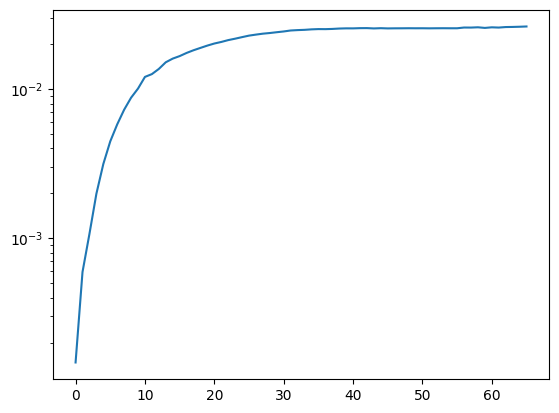

In [ ]:
import matplotlib.pyplot as plt
plt.semilogy(test_cumulative_mse)

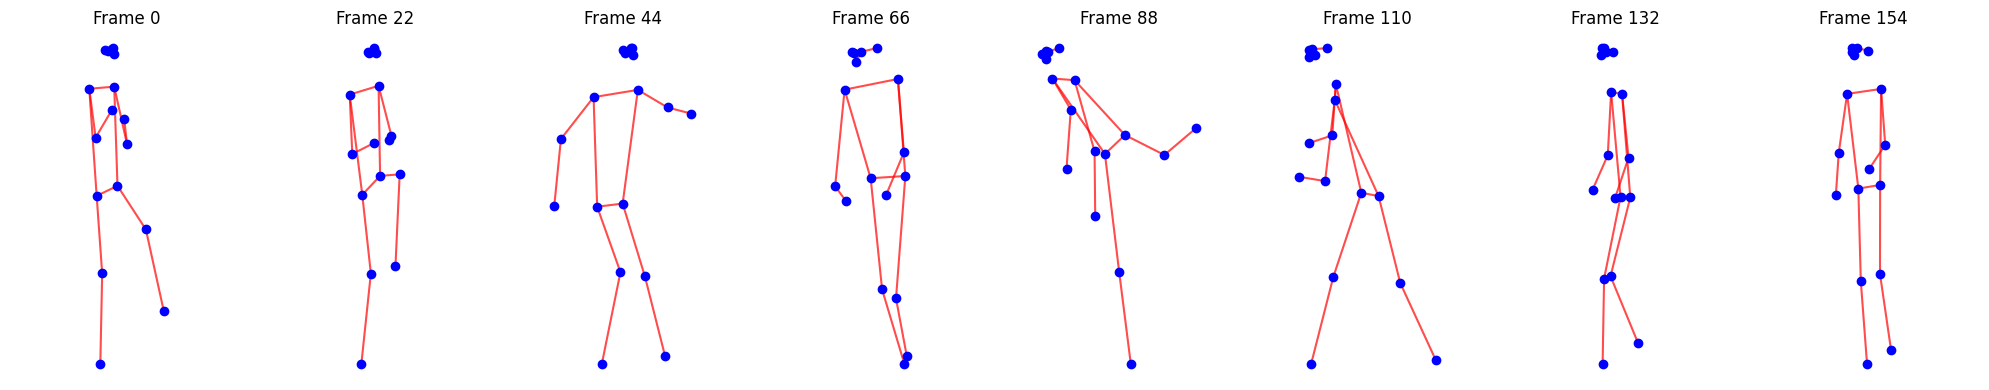

In [ ]:
sample = test_data[0]['inputs'].unsqueeze(0).cuda() # Shape: [1, 180, 17, 4]
burn_in_steps = 50
forward_steps = 130 # Predict the rest of the sequence

model.eval()
with torch.no_grad():
    # 1. Get Burn-In Edges manually from the encoder for a complete visual sequence
    burn_in_out = model.encoder(sample[:, :burn_in_steps])
    burn_in_edges = torch.sigmoid(burn_in_out['prior_logits']).cpu().squeeze(0) # Shape: [50, 32, 1]
    
    # 2. Get Predicted Future poses and their Dynamic Edges
    predictions, dynamic_edges = model.predict_future(sample[:, :burn_in_steps], forward_steps, return_edges=True)
    
    # 3. Combine them into full 180-frame tensors
    full_prediction = torch.cat([sample[:, :burn_in_steps].cpu(), predictions.cpu()], dim=1).squeeze(0)
    full_edges = torch.cat([burn_in_edges, dynamic_edges.squeeze(0).cpu()], dim=0) # Shape: [180, 32, 1]

actual = sample.squeeze(0).cpu()

# Plotting Comparison with Fading Continuous Edges
plt.figure(figsize=(20, 4))
for idx, frame_num in enumerate(range(0, DATA_LEN, DATA_LEN//9), 1):
    ax = plt.subplot(1, 9, idx)
    
    pos_act = actual[frame_num, :, :2].numpy()
    pos_pred = full_prediction[frame_num, :, :2].numpy()
    
    # Extract the 32 continuous edge weights for this specific frame
    frame_edge_weights = full_edges[frame_num, :, 0].numpy() 

    for edge_idx, (i, j) in enumerate(coco_connections):
        # Our send/recv arrays in the Encoder were built by adding [i, j] and [j, i] sequentially.
        # So the bidirectional weights for connection `edge_idx` are at index 2*edge_idx and 2*edge_idx + 1.
        # We average them to get a single connection strength between 0.0 and 1.0.
        weight = (frame_edge_weights[2 * edge_idx] + frame_edge_weights[2 * edge_idx + 1]) / 2.0
        
        # Map the continuous weight to visual properties 
        dynamic_alpha = max(0.05, float(weight)) # Keep a minimum of 0.05 so the skeleton doesn't vanish entirely
        dynamic_lw = 0.5 + (3.0 * float(weight)) # Line thickness scales from 0.5 to 3.5 based on strength

        # Plot Actual (Blue) - Static, faint background reference
        ax.plot([pos_act[i, 0], pos_act[j, 0]], [pos_act[i, 1], pos_act[j, 1]], 
                color='blue', alpha=0.15, linewidth=1.0, label='Actual' if idx==1 and edge_idx==0 else "")
        
        # Plot Prediction (Red) - Dynamically fading and thickening!
        ax.plot([pos_pred[i, 0], pos_pred[j, 0]], [pos_pred[i, 1], pos_pred[j, 1]], 
                color='red', linestyle='-', alpha=dynamic_alpha, linewidth=dynamic_lw, 
                label='Predicted' if idx==1 and edge_idx==0 else "")

    ax.set_title(f'Frame {frame_num}')
    ax.axis('equal')
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
# Place a single legend outside the plots
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()